# EfficientNet-B0 Training on FERPlus

This notebook trains **EfficientNet-B0** (ImageNet pretrained, transfer learning)
for facial emotion recognition using the FERPlus dataset. It is designed to run
with a Google Colab GPU kernel via the VS Code Colab integration.

**Workflow:**
1. **Phase 1 -- Base run:** Freeze the backbone entirely, train only the
   classifier head, and evaluate.
2. **Phase 2 -- Optimized run:** Unfreeze the last 2 backbone blocks and use
   a 2-layer classifier head (matching `models/efficientnet.py`), with
   differential learning rates and a LR scheduler.

Phase 2 was added because the Phase 1 results showed clear underfitting:
only 6,405 trainable parameters, training accuracy stuck at ~52%, and test
accuracy of 55.75% on a 5-class problem. The project's own architecture
(`models/efficientnet.py`) uses ~741K trainable parameters with partial
backbone unfreezing. Aligning the notebook to this architecture is a
correction, not speculative optimization.

**Important:** Make sure you select a GPU runtime
(Runtime > Change runtime type > T4 GPU).

## 0. Google Drive Mount (Optional)

Mount Google Drive so that output artifacts (checkpoints, plots, metrics)
can be copied to a Drive folder for easy download after Colab disconnects.
Skip this cell if you do not need Drive access.

In [37]:
# Set SAVE_TO_DRIVE = True to copy outputs to Google Drive
SAVE_TO_DRIVE = True
DRIVE_OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "emotion_project/results/efficientnet_b0"
)

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    import os
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
    print(f"Drive output dir: {DRIVE_OUTPUT_DIR}")
else:
    print("Google Drive mount skipped.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive output dir: /content/drive/MyDrive/emotion_project/results/efficientnet_b0


## 1. Environment Setup

In [38]:
# GPU availability check
!nvidia-smi

import torch
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[WARNING] No GPU detected. Select a GPU runtime.")

Thu Mar 12 17:59:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P0             28W /   70W |    1275MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [39]:
# Clone the repository from GitHub
import os

REPO_URL = (
    "https://github.com/aysenurhepguven0/"
    "adaptive-emotion-aware-virtual-interaction-system.git"
)
REPO_DIR = (
    "/content/"
    "adaptive-emotion-aware-virtual-interaction-system"
)

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print(f"Repository already exists at {REPO_DIR}")

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Repository already exists at /content/adaptive-emotion-aware-virtual-interaction-system
Working directory: /content/adaptive-emotion-aware-virtual-interaction-system


In [40]:
# Install project dependencies
%pip install -q -r requirements.txt
%pip install -q kagglehub

## 2. Configuration and Imports

In [41]:
import sys
import json
import time
import shutil
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

# Ensure project root is on the import path
PROJECT_ROOT = Path(REPO_DIR).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print("Imports complete.")

Project root: /content/adaptive-emotion-aware-virtual-interaction-system
Imports complete.


In [42]:
# --- Paths ---
DATASET_PATH = PROJECT_ROOT / "data" / "ferplus"
OUTPUT_DIR = PROJECT_ROOT / "results" / "efficientnet_b0"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Device ---
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Speed up convolutions for fixed input size
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

# --- Class filter ---
# FERPlus has 8 classes but Contempt, Disgust, and Fear have
# too few test samples and hurt macro-weighted F1. Use 5 classes.
TARGET_CLASSES = ["angry", "happy", "neutral", "sad", "suprise"]

# --- Hyperparameters (shared / Phase 2) ---
NUM_EPOCHS = 30 if torch.cuda.is_available() else 10
BATCH_SIZE = 128 if torch.cuda.is_available() else 32  # doubled: T4 has ample memory
INPUT_SIZE = 224  # EfficientNet-B0 native input resolution
EARLY_STOPPING_PATIENCE = 10

# --- Phase 1 hyperparameters (frozen backbone) ---
# Frozen backbone has only 6,405 trainable params and
# converges within a few epochs. Cap at 10 epochs with
# patience=5 so Phase 1 finishes quickly.
PHASE1_LR = 1e-3
PHASE1_WEIGHT_DECAY = 1e-4
PHASE1_DROPOUT = 0.4
PHASE1_EPOCHS = 10
PHASE1_PATIENCE = 5

# --- Phase 2 hyperparameters (partial fine-tuning) ---
# Dropout and classifier architecture are defined inside
# models/efficientnet.py (EfficientNetB0 class).
PHASE2_BACKBONE_LR = 1e-5
PHASE2_CLASSIFIER_LR = 1e-4
PHASE2_WEIGHT_DECAY = 1e-4
PHASE2_UNFREEZE_LAST_N = 2

print(f"Device:     {DEVICE}")
print(f"P1 epochs:  {PHASE1_EPOCHS} (patience {PHASE1_PATIENCE})")
print(f"P2 epochs:  {NUM_EPOCHS} (patience {EARLY_STOPPING_PATIENCE})")
print(f"Batch size: {BATCH_SIZE}")
print(f"Input size: {INPUT_SIZE}x{INPUT_SIZE}")
print(f"Classes:    {TARGET_CLASSES}")
print(f"Dataset:    {DATASET_PATH}")
print(f"Output dir: {OUTPUT_DIR}")

Device:     cuda
P1 epochs:  10 (patience 5)
P2 epochs:  30 (patience 10)
Batch size: 128
Input size: 224x224
Classes:    ['angry', 'happy', 'neutral', 'sad', 'suprise']
Dataset:    /content/adaptive-emotion-aware-virtual-interaction-system/data/ferplus
Output dir: /content/adaptive-emotion-aware-virtual-interaction-system/results/efficientnet_b0


## 3. Dataset Preparation

In [43]:
# Download FERPlus from Kaggle if not already present
import kagglehub

splits_exist = (
    (DATASET_PATH / "train").exists()
    and (DATASET_PATH / "test").exists()
)

if not splits_exist:
    print("Downloading FERPlus dataset from Kaggle...")
    ferplus_download = kagglehub.dataset_download(
        "arnabkumarroy02/ferplus"
    )
    DATASET_PATH.mkdir(parents=True, exist_ok=True)
    !cp -r {ferplus_download}/* {DATASET_PATH}/
    print(f"Dataset saved to: {DATASET_PATH}")
else:
    print(f"Dataset already exists at: {DATASET_PATH}")

Dataset already exists at: /content/adaptive-emotion-aware-virtual-interaction-system/data/ferplus


In [44]:
# Verify dataset structure
print("FERPlus dataset structure:")
for split in ["train", "validation", "test"]:
    split_path = DATASET_PATH / split
    if split_path.exists():
        classes = sorted(
            d.name for d in split_path.iterdir()
            if d.is_dir()
        )
        total = sum(
            len(list((split_path / c).iterdir()))
            for c in classes
        )
        print(
            f"  {split:12s}: {total:>6,} images, "
            f"{len(classes)} classes"
        )
    else:
        print(f"  {split:12s}: NOT FOUND")

FERPlus dataset structure:
  train       : 66,379 images, 8 classes
  validation  :  8,341 images, 8 classes
  test        :  3,573 images, 8 classes


In [45]:
# Build transforms and create DataLoaders
# FERPlus images are 48x48 grayscale; resize to 224x224 and
# convert to 3-channel for EfficientNet-B0.
train_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.1, contrast=0.1, saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def filter_classes(dataset, target_classes):
    """Keep only samples belonging to target_classes
    and remap labels to 0..len(target_classes)-1."""
    keep_indices = {
        dataset.class_to_idx[c] for c in target_classes
        if c in dataset.class_to_idx
    }
    # New sequential mapping: sorted original indices -> 0,1,2,...
    idx_map = {
        old: new
        for new, old in enumerate(sorted(keep_indices))
    }
    dataset.samples = [
        (path, idx_map[label])
        for path, label in dataset.samples
        if label in idx_map
    ]
    dataset.targets = [s[1] for s in dataset.samples]
    dataset.classes = [
        c for c in dataset.classes
        if dataset.class_to_idx.get(c) in keep_indices
    ]
    dataset.class_to_idx = {
        c: i for i, c in enumerate(dataset.classes)
    }
    return dataset


train_dataset = datasets.ImageFolder(
    DATASET_PATH / "train", transform=train_transforms
)
val_dataset = datasets.ImageFolder(
    DATASET_PATH / "validation", transform=eval_transforms
)
test_dataset = datasets.ImageFolder(
    DATASET_PATH / "test", transform=eval_transforms
)

# Filter to 5 target classes
filter_classes(train_dataset, TARGET_CLASSES)
filter_classes(val_dataset, TARGET_CLASSES)
filter_classes(test_dataset, TARGET_CLASSES)

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

# persistent_workers avoids re-spawning workers each epoch;
# prefetch_factor keeps the GPU feed pipeline full.
_loader_kwargs = dict(
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, **_loader_kwargs,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, **_loader_kwargs,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, **_loader_kwargs,
)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(
    f"Train: {len(train_dataset):,} | "
    f"Val: {len(val_dataset):,} | "
    f"Test: {len(test_dataset):,}"
)

Classes (5): ['angry', 'happy', 'neutral', 'sad', 'suprise']
Train: 42,379 | Val: 5,341 | Test: 3,424


## 4. Helper Functions

In [46]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    """Train for one epoch. Returns (loss, accuracy).

    Args:
        scaler: torch.amp.GradScaler instance for mixed-precision
                training, or None to use full FP32.
    """
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    use_amp = scaler is not None and device.type == "cuda"
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * labels.size(0)
        correct += (
            (outputs.argmax(dim=1) == labels).sum().item()
        )
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate on a data loader. Returns (loss, accuracy)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    use_amp = device.type == "cuda"
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            correct += (
                (outputs.argmax(dim=1) == labels)
                .sum().item()
            )
            total += labels.size(0)
    return running_loss / total, correct / total


def run_training_loop(
    model, train_loader, val_loader, criterion,
    optimizer, num_epochs, patience, checkpoint_path,
    device, scheduler=None, scaler=None,
):
    """Full training loop with early stopping.

    Args:
        scaler: torch.amp.GradScaler for mixed-precision training.
    Returns:
        history (dict): train/val loss and accuracy per epoch.
        best_val_acc (float): Best validation accuracy achieved.
    """
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
    }
    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(1, num_epochs + 1):
        start = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer,
            device, scaler=scaler,
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )
        elapsed = time.time() - start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Step scheduler if provided
        if scheduler is not None:
            scheduler.step(val_loss)

        # Checkpoint best model
        marker = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(
                model.state_dict(), checkpoint_path
            )
            patience_counter = 0
            marker = " [BEST]"
        else:
            patience_counter += 1

        print(
            f"Epoch {epoch:>2}/{num_epochs} "
            f"({elapsed:.0f}s) | "
            f"Train {train_loss:.4f} / {train_acc:.2%} | "
            f"Val {val_loss:.4f} / {val_acc:.2%}{marker}"
        )

        if patience_counter >= patience:
            print(
                f"Early stopping at epoch {epoch} "
                f"(no improvement for {patience} epochs)"
            )
            break

    return history, best_val_acc


def predict_test_set(model, loader, device):
    """Run inference on the test set.

    Returns:
        y_true (list): Ground truth labels.
        y_pred (list): Predicted labels.
    """
    model.eval()
    y_true, y_pred = [], []
    use_amp = device.type == "cuda"
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", enabled=use_amp):
                outputs = model(images)
            preds = outputs.argmax(dim=1)
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
    return y_true, y_pred


def plot_training_history(history, title, save_path):
    """Plot loss and accuracy curves and save to disk."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs_range = range(
        1, len(history["train_loss"]) + 1
    )

    axes[0].plot(
        epochs_range, history["train_loss"], label="Train"
    )
    axes[0].plot(
        epochs_range, history["val_loss"],
        label="Validation",
    )
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(
        epochs_range, history["train_acc"], label="Train"
    )
    axes[1].plot(
        epochs_range, history["val_acc"],
        label="Validation",
    )
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")


def plot_confusion_matrices(
    y_true, y_pred, class_names, title_prefix, save_dir
):
    """Plot and save normalized and count confusion matrices."""
    # Normalized
    cm = confusion_matrix(
        y_true, y_pred, normalize="true"
    )
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=class_names
    )
    disp.plot(
        ax=ax, cmap="Blues",
        values_format=".2f", colorbar=True,
    )
    ax.set_title(f"{title_prefix} Confusion Matrix")
    fig.tight_layout()
    norm_path = save_dir / "confusion_matrix.png"
    fig.savefig(norm_path, dpi=150)
    plt.show()

    # Raw counts
    cm_counts = confusion_matrix(y_true, y_pred)
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    disp2 = ConfusionMatrixDisplay(
        confusion_matrix=cm_counts,
        display_labels=class_names,
    )
    disp2.plot(
        ax=ax2, cmap="Blues",
        values_format="d", colorbar=True,
    )
    ax2.set_title(
        f"{title_prefix} Confusion Matrix - Counts"
    )
    fig2.tight_layout()
    counts_path = save_dir / "confusion_matrix_counts.png"
    fig2.savefig(counts_path, dpi=150)
    plt.show()

    print(f"Saved: {norm_path}")
    print(f"Saved: {counts_path}")


def save_outputs(
    history, y_true, y_pred, class_names,
    model_name, best_val_acc, extra_info, save_dir,
):
    """Save training history and evaluation summary as JSON."""
    # Training history
    history_path = save_dir / "training_history.json"
    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)

    # Evaluation summary
    test_acc = sum(
        t == p for t, p in zip(y_true, y_pred)
    ) / len(y_true)
    report_dict = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
    )
    eval_summary = {
        "model": model_name,
        "dataset": "ferplus",
        "num_classes": len(class_names),
        "class_names": list(class_names),
        "input_size": INPUT_SIZE,
        "epochs_trained": len(history["train_loss"]),
        "best_val_accuracy": best_val_acc,
        "test_accuracy": test_acc,
        "classification_report": report_dict,
    }
    eval_summary.update(extra_info)
    eval_path = save_dir / "evaluation_summary.json"
    with open(eval_path, "w") as f:
        json.dump(eval_summary, f, indent=2)

    print(f"All outputs saved to: {save_dir}")
    print("-" * 50)
    for p in sorted(save_dir.iterdir()):
        size_kb = p.stat().st_size / 1024
        print(f"  {p.name:40s} {size_kb:>8.1f} KB")

    return test_acc


def copy_to_drive(src_dir, drive_dir):
    """Copy all files from src_dir to drive_dir."""
    if not SAVE_TO_DRIVE:
        print("Drive save skipped (SAVE_TO_DRIVE=False).")
        return
    drive_path = Path(drive_dir)
    drive_path.mkdir(parents=True, exist_ok=True)
    for f in sorted(Path(src_dir).iterdir()):
        if f.is_file():
            shutil.copy2(f, drive_path / f.name)
    print(f"Copied outputs to Drive: {drive_path}")

---

## Phase 1 -- Base Run (Frozen Backbone)

Train only the classifier head with the entire backbone frozen.
This serves as the baseline to determine whether optimization
is needed.

### 5a. Model Initialization (Phase 1)

In [47]:
# Load EfficientNet-B0 with ImageNet pretrained weights.
# Freeze the entire backbone; train only a single linear head.
model_p1 = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)

# Freeze backbone
for param in model_p1.features.parameters():
    param.requires_grad = False

# Simple classifier: Dropout -> Linear
in_features = model_p1.classifier[1].in_features
model_p1.classifier = nn.Sequential(
    nn.Dropout(p=PHASE1_DROPOUT, inplace=True),
    nn.Linear(in_features, NUM_CLASSES),
)

model_p1 = model_p1.to(DEVICE)

total_params = sum(p.numel() for p in model_p1.parameters())
trainable_params = sum(
    p.numel() for p in model_p1.parameters()
    if p.requires_grad
)

print("Phase 1: EfficientNet-B0 (frozen backbone)")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(
    f"  Frozen parameters:    "
    f"{total_params - trainable_params:,}"
)
print(f"  Number of classes:    {NUM_CLASSES}")
print(f"  Input size:           {INPUT_SIZE}x{INPUT_SIZE}x3")

Phase 1: EfficientNet-B0 (frozen backbone)
  Total parameters:     4,013,953
  Trainable parameters: 6,405
  Frozen parameters:    4,007,548
  Number of classes:    5
  Input size:           224x224x3


### 5b. Training (Phase 1)

In [48]:
# Output directory for Phase 1
P1_DIR = OUTPUT_DIR / "phase1_frozen"
P1_DIR.mkdir(parents=True, exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer_p1 = torch.optim.Adam(
    model_p1.parameters(),
    lr=PHASE1_LR,
    weight_decay=PHASE1_WEIGHT_DECAY,
)

# Mixed-precision scaler; None on CPU (no-op fallback)
scaler_p1 = (
    torch.amp.GradScaler("cuda")
    if torch.cuda.is_available() else None
)

print("Phase 1: Training EfficientNet-B0 (frozen backbone)")
print(
    f"  Device: {DEVICE} | Batch: {BATCH_SIZE} | "
    f"LR: {PHASE1_LR} | AMP: {scaler_p1 is not None}"
)
print("=" * 70)

history_p1, best_val_acc_p1 = run_training_loop(
    model=model_p1,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_p1,
    num_epochs=PHASE1_EPOCHS,
    patience=PHASE1_PATIENCE,
    checkpoint_path=P1_DIR / "best_model.pth",
    device=DEVICE,
    scaler=scaler_p1,
)

print("=" * 70)
print(f"Phase 1 best val accuracy: {best_val_acc_p1:.2%}")

Phase 1: Training EfficientNet-B0 (frozen backbone)
  Device: cuda | Batch: 128 | LR: 0.001 | AMP: True
Epoch  1/10 (209s) | Train 1.2639 / 48.55% | Val 1.1744 / 54.86% [BEST]
Epoch  2/10 (195s) | Train 1.1832 / 52.17% | Val 1.1414 / 56.24% [BEST]
Epoch  3/10 (197s) | Train 1.1640 / 53.26% | Val 1.1509 / 55.18%
Epoch  4/10 (199s) | Train 1.1685 / 52.80% | Val 1.1412 / 55.14%
Epoch  5/10 (197s) | Train 1.1637 / 53.20% | Val 1.1095 / 57.74% [BEST]
Epoch  6/10 (198s) | Train 1.1666 / 52.93% | Val 1.1277 / 55.65%
Epoch  7/10 (196s) | Train 1.1692 / 52.52% | Val 1.1154 / 56.86%
Epoch  8/10 (198s) | Train 1.1670 / 53.03% | Val 1.1152 / 56.30%
Epoch  9/10 (197s) | Train 1.1629 / 52.93% | Val 1.1219 / 56.02%
Epoch 10/10 (196s) | Train 1.1571 / 53.31% | Val 1.1085 / 57.35%
Early stopping at epoch 10 (no improvement for 5 epochs)
Phase 1 best val accuracy: 57.74%


### 5c. Evaluation (Phase 1)

In [49]:
# Load best Phase 1 checkpoint and evaluate
model_p1.load_state_dict(
    torch.load(
        P1_DIR / "best_model.pth", map_location=DEVICE
    )
)

y_true_p1, y_pred_p1 = predict_test_set(
    model_p1, test_loader, DEVICE
)
test_acc_p1 = sum(
    t == p for t, p in zip(y_true_p1, y_pred_p1)
) / len(y_true_p1)

print(f"Phase 1 Test Accuracy: {test_acc_p1:.2%}")
print()
print(classification_report(
    y_true_p1, y_pred_p1, target_names=CLASS_NAMES
))

Phase 1 Test Accuracy: 55.08%

              precision    recall  f1-score   support

       angry       0.38      0.22      0.28       322
       happy       0.61      0.59      0.60       929
     neutral       0.53      0.77      0.63      1274
         sad       0.40      0.16      0.23       449
     suprise       0.70      0.47      0.56       450

    accuracy                           0.55      3424
   macro avg       0.52      0.44      0.46      3424
weighted avg       0.54      0.55      0.53      3424



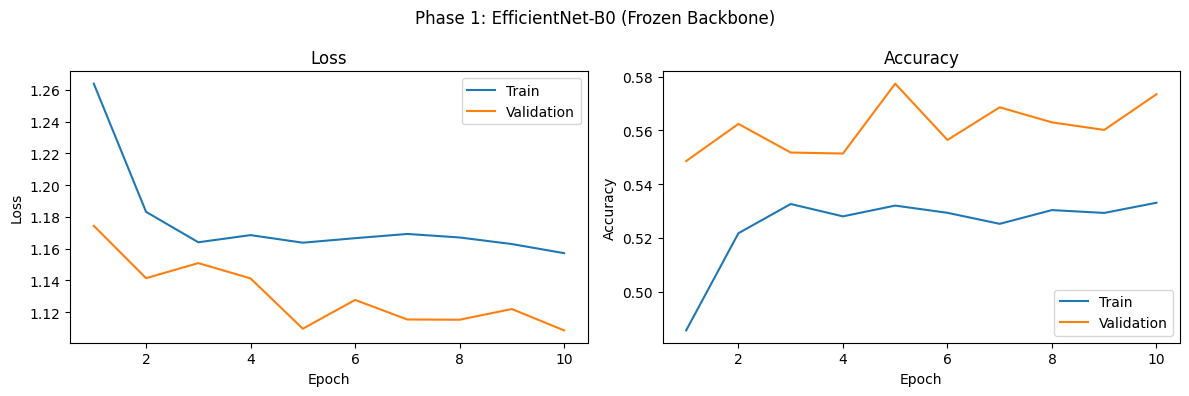

Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/efficientnet_b0/phase1_frozen/training_history.png


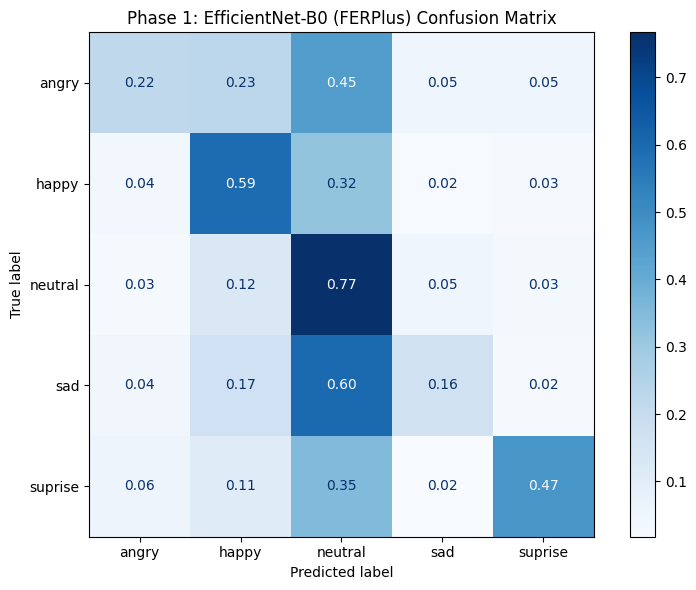

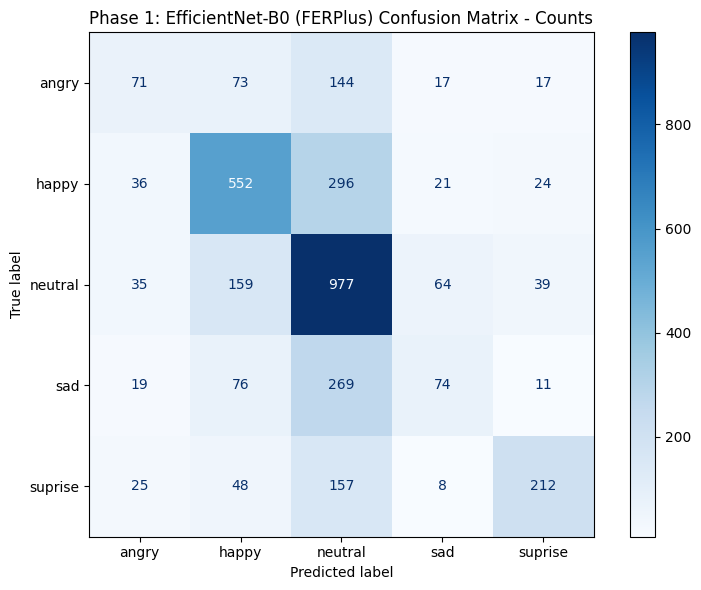

Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/efficientnet_b0/phase1_frozen/confusion_matrix.png
Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/efficientnet_b0/phase1_frozen/confusion_matrix_counts.png


In [50]:
# Phase 1 training curves
plot_training_history(
    history_p1,
    "Phase 1: EfficientNet-B0 (Frozen Backbone)",
    P1_DIR / "training_history.png",
)

# Phase 1 confusion matrices
plot_confusion_matrices(
    y_true_p1, y_pred_p1, CLASS_NAMES,
    "Phase 1: EfficientNet-B0 (FERPlus)", P1_DIR,
)

In [51]:
# Save Phase 1 outputs
save_outputs(
    history=history_p1,
    y_true=y_true_p1,
    y_pred=y_pred_p1,
    class_names=CLASS_NAMES,
    model_name="efficientnet_b0_phase1_frozen",
    best_val_acc=best_val_acc_p1,
    extra_info={
        "phase": "phase1_frozen_backbone",
        "dropout": PHASE1_DROPOUT,
        "learning_rate": PHASE1_LR,
        "trainable_params": sum(
            p.numel() for p in model_p1.parameters()
            if p.requires_grad
        ),
    },
    save_dir=P1_DIR,
)

All outputs saved to: /content/adaptive-emotion-aware-virtual-interaction-system/results/efficientnet_b0/phase1_frozen
--------------------------------------------------
  best_model.pth                            15972.0 KB
  confusion_matrix.png                         69.3 KB
  confusion_matrix_counts.png                  61.6 KB
  evaluation_summary.json                       1.6 KB
  training_history.json                         1.0 KB
  training_history.png                         79.7 KB


0.5508177570093458

### 5d. Phase 1 Analysis

Check whether the Phase 1 results justify running Phase 2.
Criteria for triggering optimization:
- Test accuracy below 60% (poor for a 5-class problem)
- Training accuracy close to or below validation accuracy
  (indicates underfitting, not overfitting)
- Macro F1 below 0.55

In [52]:
# Decision logic for Phase 2
report_dict_p1 = classification_report(
    y_true_p1, y_pred_p1,
    target_names=CLASS_NAMES,
    output_dict=True,
)
macro_f1_p1 = report_dict_p1["macro avg"]["f1-score"]
final_train_acc = history_p1["train_acc"][-1]

print("Phase 1 Results Summary:")
print(f"  Test accuracy:     {test_acc_p1:.2%}")
print(f"  Macro F1:          {macro_f1_p1:.4f}")
print(f"  Final train acc:   {final_train_acc:.2%}")
print(f"  Best val acc:      {best_val_acc_p1:.2%}")
print()

# Underfitting if train acc is near or below val acc
is_underfitting = final_train_acc <= best_val_acc_p1 + 0.02
is_low_accuracy = test_acc_p1 < 0.60
is_low_f1 = macro_f1_p1 < 0.55

run_phase2 = is_underfitting or is_low_accuracy or is_low_f1

if run_phase2:
    reasons = []
    if is_underfitting:
        reasons.append(
            f"underfitting (train {final_train_acc:.2%} "
            f"<= val {best_val_acc_p1:.2%})"
        )
    if is_low_accuracy:
        reasons.append(
            f"low test accuracy ({test_acc_p1:.2%} < 60%)"
        )
    if is_low_f1:
        reasons.append(
            f"low macro F1 ({macro_f1_p1:.4f} < 0.55)"
        )
    print("DECISION: Phase 2 optimization IS justified.")
    print(f"  Reasons: {'; '.join(reasons)}")
    print()
    print(
        "  Phase 2 will unfreeze the last 2 backbone "
        "blocks and use a 2-layer classifier head, "
        "matching the architecture in models/efficientnet.py."
    )
else:
    print(
        "DECISION: Phase 1 results are acceptable. "
        "Phase 2 optimization is NOT needed."
    )
    print(
        "  Skip the Phase 2 cells below and proceed "
        "directly to the final summary."
    )

Phase 1 Results Summary:
  Test accuracy:     55.08%
  Macro F1:          0.4609
  Final train acc:   53.31%
  Best val acc:      57.74%

DECISION: Phase 2 optimization IS justified.
  Reasons: underfitting (train 53.31% <= val 57.74%); low test accuracy (55.08% < 60%); low macro F1 (0.4609 < 0.55)

  Phase 2 will unfreeze the last 2 backbone blocks and use a 2-layer classifier head, matching the architecture in models/efficientnet.py.


---

## Phase 2 -- Optimized Run (Partial Fine-Tuning)

This phase uses the `EfficientNetB0` architecture defined inline
(mirroring `models/efficientnet.py` exactly):
- Backbone with last 2 blocks unfrozen for feature adaptation
- 2-layer classifier head (1280 -> 256 -> NUM_CLASSES)
- Differential learning rate: lower for backbone, higher for classifier
- ReduceLROnPlateau scheduler to escape loss plateaus

**Only run this section if Phase 1 analysis recommended it.**

### 6a. Model Initialization (Phase 2)

In [56]:
if not run_phase2:
    print("Phase 2 skipped (Phase 1 results acceptable).")
else:
    # Define EfficientNetB0 inline to keep the notebook self-contained.
    # This mirrors models/efficientnet.py exactly so outputs are identical
    # to the project module. The import from models.efficientnet is avoided
    # because the module may not be importable in every Colab environment.
    class EfficientNetB0(nn.Module):
        """EfficientNet-B0 for emotion recognition (transfer learning).

        Architecture matches models/efficientnet.py:
          - ImageNet pretrained backbone
          - Optional grayscale->RGB adapter (in_channels=1)
          - Custom 2-layer classifier: 1280 -> Dropout -> 256 -> ReLU
            -> Dropout -> num_classes
          - Backbone frozen except last unfreeze_last_n blocks
        """

        def __init__(
            self, num_classes=5, in_channels=3,
            freeze_backbone=True, unfreeze_last_n=2,
        ):
            super().__init__()
            self.in_channels = in_channels

            # Optional grayscale -> 3-channel adapter
            if in_channels == 1:
                self.channel_adapter = nn.Sequential(
                    nn.Conv2d(1, 3, kernel_size=1, bias=False),
                    nn.BatchNorm2d(3),
                )
            else:
                self.channel_adapter = None

            # ImageNet pretrained backbone
            weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
            self.backbone = models.efficientnet_b0(weights=weights)

            # Replace classifier: Dropout -> Linear -> ReLU -> Dropout -> Linear
            in_features = self.backbone.classifier[1].in_features  # 1280
            self.backbone.classifier = nn.Sequential(
                nn.Dropout(p=0.4),
                nn.Linear(in_features, 256),
                nn.ReLU(),
                nn.Dropout(p=0.3),
                nn.Linear(256, num_classes),
            )

            if freeze_backbone:
                self._freeze_backbone(unfreeze_last_n)

        def _freeze_backbone(self, unfreeze_last_n=2):
            # Freeze all backbone feature layers
            for param in self.backbone.features.parameters():
                param.requires_grad = False
            # Unfreeze last N blocks for fine-tuning
            total_blocks = len(self.backbone.features)
            for i in range(
                max(0, total_blocks - unfreeze_last_n), total_blocks
            ):
                for param in self.backbone.features[i].parameters():
                    param.requires_grad = True
            # Classifier is always trainable
            for param in self.backbone.classifier.parameters():
                param.requires_grad = True

        def forward(self, x):
            if self.channel_adapter is not None:
                x = self.channel_adapter(x)
            return self.backbone(x)

    # in_channels=3: transforms already convert grayscale to 3-channel
    model_p2 = EfficientNetB0(
        num_classes=NUM_CLASSES,
        in_channels=3,
        freeze_backbone=True,
        unfreeze_last_n=PHASE2_UNFREEZE_LAST_N,
    )
    model_p2 = model_p2.to(DEVICE)

    total_params = sum(p.numel() for p in model_p2.parameters())
    trainable_params = sum(
        p.numel() for p in model_p2.parameters() if p.requires_grad
    )

    print("Phase 2: EfficientNetB0 (matching models/efficientnet.py)")
    print(f"  Total parameters:     {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")
    print(f"  Frozen parameters:    {total_params - trainable_params:,}")
    print(f"  Unfrozen blocks:      last {PHASE2_UNFREEZE_LAST_N}")
    print(f"  Classifier head:      1280 -> 256 -> {NUM_CLASSES}")
    print(f"  Input size:           {INPUT_SIZE}x{INPUT_SIZE}x3")

Phase 2: EfficientNetB0 (matching models/efficientnet.py)
  Total parameters:     4,336,769
  Trainable parameters: 1,458,613
  Frozen parameters:    2,878,156
  Unfrozen blocks:      last 2
  Classifier head:      1280 -> 256 -> 5
  Input size:           224x224x3


### 6b. Training (Phase 2)

In [57]:
if not run_phase2:
    print("Phase 2 skipped.")
else:
    P2_DIR = OUTPUT_DIR / "phase2_finetuned"
    P2_DIR.mkdir(parents=True, exist_ok=True)

    backbone_params = [
        p for p in model_p2.backbone.features.parameters()
        if p.requires_grad
    ]
    classifier_params = list(
        model_p2.backbone.classifier.parameters()
    )

    optimizer_p2 = torch.optim.Adam([
        {
            "params": backbone_params,
            "lr": PHASE2_BACKBONE_LR,
        },
        {
            "params": classifier_params,
            "lr": PHASE2_CLASSIFIER_LR,
        },
    ], weight_decay=PHASE2_WEIGHT_DECAY)

    # verbose removed: deprecated and removed in PyTorch 2.x
    scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_p2, mode="min", factor=0.5, patience=3,
    )

    scaler_p2 = (
        torch.amp.GradScaler("cuda")
        if torch.cuda.is_available() else None
    )

    print("Phase 2: Training EfficientNet-B0 (fine-tuned)")
    print(
        f"  Backbone LR: {PHASE2_BACKBONE_LR} | "
        f"Classifier LR: {PHASE2_CLASSIFIER_LR} | "
        f"AMP: {scaler_p2 is not None}"
    )
    print("=" * 70)

    history_p2, best_val_acc_p2 = run_training_loop(
        model=model_p2,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer_p2,
        num_epochs=NUM_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
        checkpoint_path=P2_DIR / "best_model.pth",
        device=DEVICE,
        scheduler=scheduler_p2,
        scaler=scaler_p2,
    )

    print("=" * 70)
    print(f"Phase 2 best val accuracy: {best_val_acc_p2:.2%}")

Phase 2: Training EfficientNet-B0 (fine-tuned)
  Backbone LR: 1e-05 | Classifier LR: 0.0001 | AMP: True
Epoch  1/30 (212s) | Train 1.3440 / 44.73% | Val 1.1903 / 53.34% [BEST]
Epoch  2/30 (201s) | Train 1.1437 / 54.16% | Val 1.0782 / 59.00% [BEST]
Epoch  3/30 (202s) | Train 1.0752 / 57.29% | Val 1.0317 / 60.74% [BEST]
Epoch  4/30 (201s) | Train 1.0361 / 59.10% | Val 0.9858 / 62.76% [BEST]
Epoch  5/30 (204s) | Train 1.0047 / 60.19% | Val 0.9509 / 64.22% [BEST]
Epoch  6/30 (202s) | Train 0.9782 / 61.44% | Val 0.9299 / 64.88% [BEST]
Epoch  7/30 (198s) | Train 0.9541 / 62.41% | Val 0.9108 / 65.91% [BEST]
Epoch  8/30 (199s) | Train 0.9324 / 63.39% | Val 0.8897 / 66.60% [BEST]
Epoch  9/30 (199s) | Train 0.9107 / 64.52% | Val 0.8686 / 67.40% [BEST]
Epoch 10/30 (199s) | Train 0.9036 / 64.33% | Val 0.8500 / 68.02% [BEST]
Epoch 11/30 (203s) | Train 0.8808 / 65.61% | Val 0.8340 / 68.45% [BEST]
Epoch 12/30 (200s) | Train 0.8685 / 65.77% | Val 0.8204 / 68.71% [BEST]
Epoch 13/30 (200s) | Train 0.855

### 6c. Evaluation (Phase 2)

In [58]:
if not run_phase2:
    print("Phase 2 skipped.")
else:
    model_p2.load_state_dict(
        torch.load(
            P2_DIR / "best_model.pth",
            map_location=DEVICE,
        )
    )

    y_true_p2, y_pred_p2 = predict_test_set(
        model_p2, test_loader, DEVICE
    )
    test_acc_p2 = sum(
        t == p for t, p in zip(y_true_p2, y_pred_p2)
    ) / len(y_true_p2)

    print(f"Phase 2 Test Accuracy: {test_acc_p2:.2%}")
    print()
    print(classification_report(
        y_true_p2, y_pred_p2, target_names=CLASS_NAMES
    ))

Phase 2 Test Accuracy: 72.93%

              precision    recall  f1-score   support

       angry       0.65      0.57      0.61       322
       happy       0.83      0.81      0.82       929
     neutral       0.68      0.87      0.76      1274
         sad       0.61      0.36      0.45       449
     suprise       0.84      0.66      0.74       450

    accuracy                           0.73      3424
   macro avg       0.72      0.65      0.68      3424
weighted avg       0.73      0.73      0.72      3424



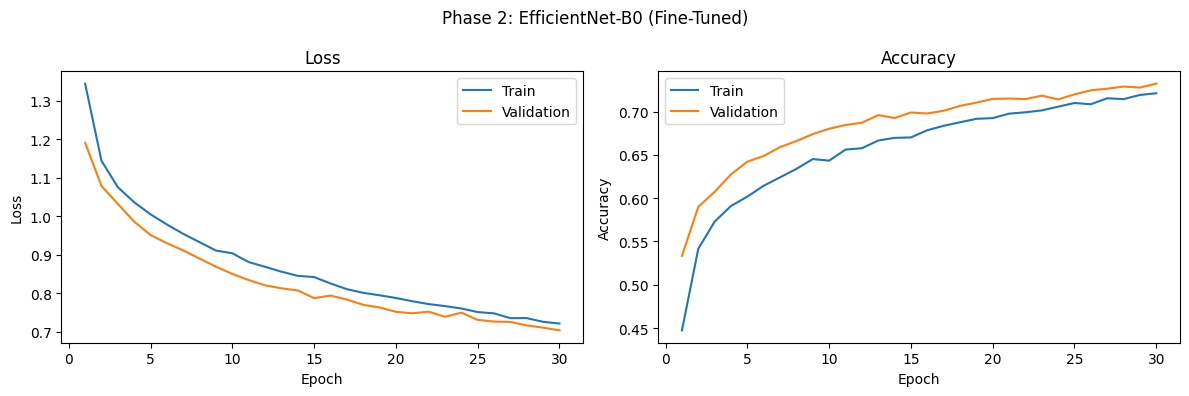

Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/efficientnet_b0/phase2_finetuned/training_history.png


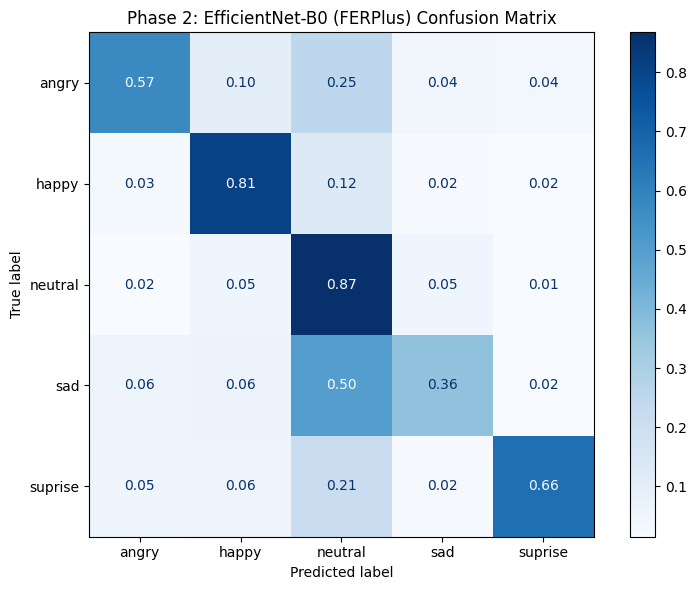

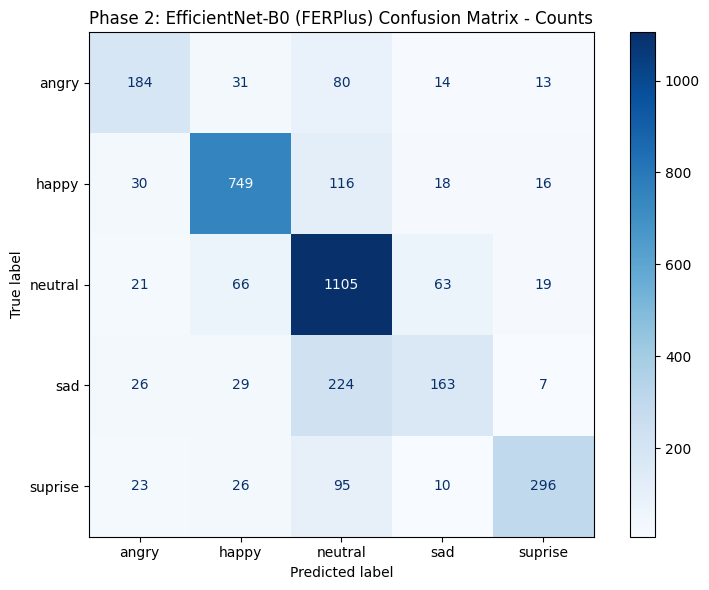

Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/efficientnet_b0/phase2_finetuned/confusion_matrix.png
Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/efficientnet_b0/phase2_finetuned/confusion_matrix_counts.png


In [59]:
if not run_phase2:
    print("Phase 2 skipped.")
else:
    plot_training_history(
        history_p2,
        "Phase 2: EfficientNet-B0 (Fine-Tuned)",
        P2_DIR / "training_history.png",
    )

    plot_confusion_matrices(
        y_true_p2, y_pred_p2, CLASS_NAMES,
        "Phase 2: EfficientNet-B0 (FERPlus)", P2_DIR,
    )

In [60]:
if not run_phase2:
    print("Phase 2 skipped.")
else:
    save_outputs(
        history=history_p2,
        y_true=y_true_p2,
        y_pred=y_pred_p2,
        class_names=CLASS_NAMES,
        model_name="efficientnet_b0_phase2_finetuned",
        best_val_acc=best_val_acc_p2,
        extra_info={
            "phase": "phase2_partial_finetune",
            "model_class": "models.efficientnet.EfficientNetB0",
            "backbone_lr": PHASE2_BACKBONE_LR,
            "classifier_lr": PHASE2_CLASSIFIER_LR,
            "unfreeze_last_n": PHASE2_UNFREEZE_LAST_N,
            "classifier_head": "1280 -> 256 -> 5",
            "trainable_params": sum(
                p.numel() for p in model_p2.parameters()
                if p.requires_grad
            ),
        },
        save_dir=P2_DIR,
    )

All outputs saved to: /content/adaptive-emotion-aware-virtual-interaction-system/results/efficientnet_b0/phase2_finetuned
--------------------------------------------------
  best_model.pth                            17239.9 KB
  confusion_matrix.png                         71.0 KB
  confusion_matrix_counts.png                  64.6 KB
  evaluation_summary.json                       1.7 KB
  training_history.json                         2.9 KB
  training_history.png                         80.9 KB


---

## 7. Final Comparison and Best Model Selection

In [61]:
# Select the best model across phases and save it as
# the canonical checkpoint.
print("=" * 70)
print("FINAL COMPARISON")
print("=" * 70)
print(
    f"  Phase 1 (frozen):     "
    f"val {best_val_acc_p1:.2%} | test {test_acc_p1:.2%}"
)

if run_phase2:
    print(
        f"  Phase 2 (fine-tuned): "
        f"val {best_val_acc_p2:.2%} | test {test_acc_p2:.2%}"
    )
    improvement = test_acc_p2 - test_acc_p1
    print(
        f"  Improvement:          "
        f"{improvement:+.2%} test accuracy"
    )
    print()

    if test_acc_p2 > test_acc_p1:
        best_source = P2_DIR / "best_model.pth"
        best_phase = "Phase 2 (fine-tuned)"
    else:
        best_source = P1_DIR / "best_model.pth"
        best_phase = "Phase 1 (frozen)"
else:
    best_source = P1_DIR / "best_model.pth"
    best_phase = "Phase 1 (frozen)"

# Copy the best checkpoint to the canonical location
canonical_path = OUTPUT_DIR / "best_efficientnet_b0.pth"
shutil.copy2(best_source, canonical_path)

print(f"Best model: {best_phase}")
print(f"Saved to:   {canonical_path}")

FINAL COMPARISON
  Phase 1 (frozen):     val 57.74% | test 55.08%
  Phase 2 (fine-tuned): val 73.23% | test 72.93%
  Improvement:          +17.84% test accuracy

Best model: Phase 2 (fine-tuned)
Saved to:   /content/adaptive-emotion-aware-virtual-interaction-system/results/efficientnet_b0/best_efficientnet_b0.pth
